#### Code for generating figure 1

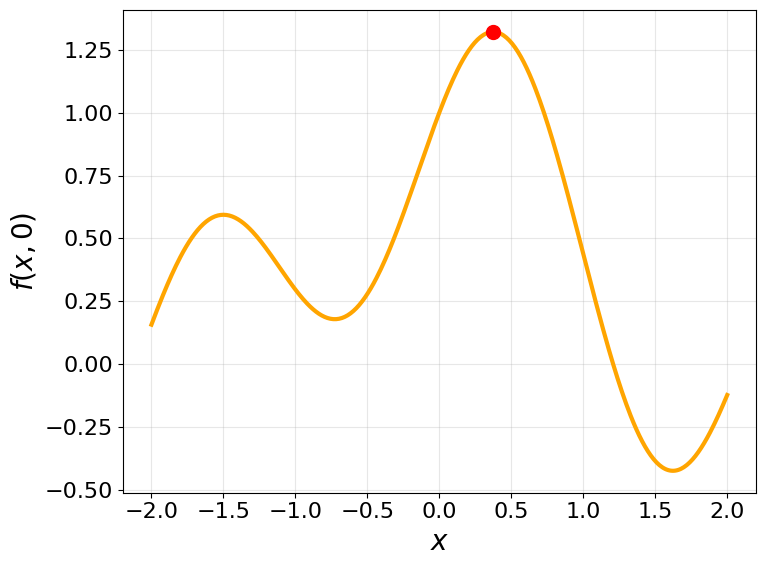

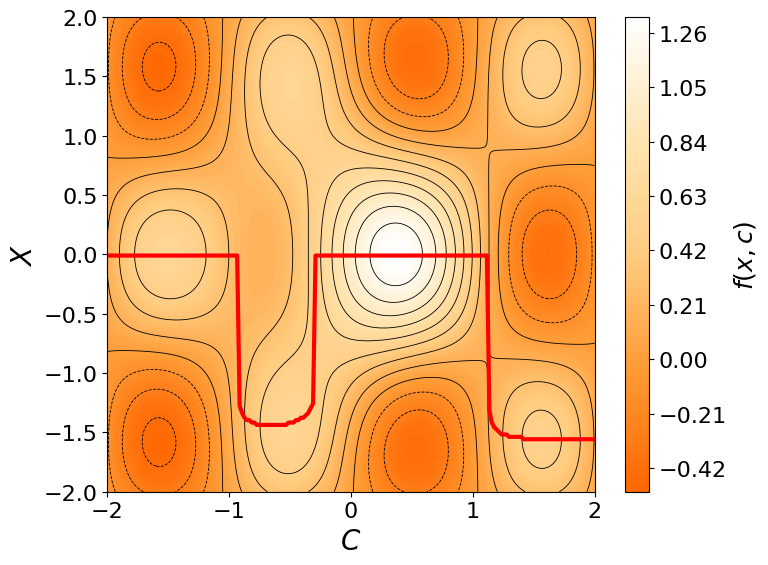

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ----------------------------
# 1) Define function f(x, c)
# ----------------------------
def f(x, c):
    return np.exp(-x**2 - c**2) + 0.5 * np.sin(3 * x) * np.cos(2 * c)

# ----------------------------
# 2) Fix c = 0 and sample x
# ----------------------------
c_fixed = 0.0
x = np.linspace(-2, 2, 400)
y = f(x, c_fixed)

# ----------------------------
# 3) Find the optimal x* and f(x*, 0)
# ----------------------------
x_star = x[np.argmax(y)]
y_star = np.max(y)

# ----------------------------
# 4) Plot with larger fonts
# ----------------------------
plt.figure(figsize=(8, 6))

# Set global font sizes for consistency
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
})

# Plot function curve
plt.plot(x, y, color='orange', linewidth=3, label=fr'$f(x, c=0)$')

# Mark optimal point with red dot
plt.plot(x_star, y_star, 'ro', markersize=10)


# Labels and grid
plt.xlabel('$x$')
plt.ylabel('$f(x, 0)$')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# 1) Define function f(x, c)
# ----------------------------
def f(X, C):
    # A smooth, nontrivial function
    return np.exp(-X**2 - C**2) + 0.5 * np.sin(3 * X) * np.cos(2 * C)

# ----------------------------
# 2) Grid over x and c
# ----------------------------
x = np.linspace(-2, 2, 200)
c = np.linspace(-2, 2, 200)
X, C = np.meshgrid(x, c)
Z = f(X, C)

# ----------------------------
# 3) Compute ridge: c*(x) = argmax_c f(x, c)
# ----------------------------
best_c = np.empty_like(x)
for i in range(len(x)):
    j = np.argmax(Z[:, i])
    best_c[i] = c[j]

# ----------------------------
# 4) Find the global maximum
# ----------------------------
max_idx = np.unravel_index(np.argmax(Z), Z.shape)
x_star, c_star = X[max_idx], C[max_idx]

# ----------------------------
# 5) Define custom orange → white colormap
# ----------------------------
colors = ["#ff6600", "#ff9933", "#ffcc80", "#ffe6b3", "#ffffff"]
orange_white_cmap = LinearSegmentedColormap.from_list("orange_white", colors)

# ----------------------------
# 6) Plot with larger fonts and thicker visuals
# ----------------------------
plt.figure(figsize=(8, 6))

# Increase global font sizes
plt.rcParams.update({
    'font.size': 18,         # base font size
    'axes.titlesize': 20,    # title font
    'axes.labelsize': 20,    # x/y labels
    'xtick.labelsize': 16,   # tick labels
    'ytick.labelsize': 16,   
    'legend.fontsize': 16,   
})

# Filled contour
contourf = plt.contourf(X, C, Z, levels=60, cmap=orange_white_cmap)
cbar = plt.colorbar(contourf)
cbar.ax.tick_params(labelsize=16)
cbar.set_label('$f(x, c)$', fontsize=18)

# Optional contour lines
plt.contour(X, C, Z, levels=12, colors='k', linewidths=0.6)

# Red ridge: c*(x)
plt.plot(x, best_c, color='red', linewidth=3, label=r'$c^*(x) = \arg\max_c f(x,c)$')

# Labels & layout
plt.xlabel('$C$')
plt.ylabel('$X$')
plt.tight_layout()
plt.show()


### Code for generating Figure 2

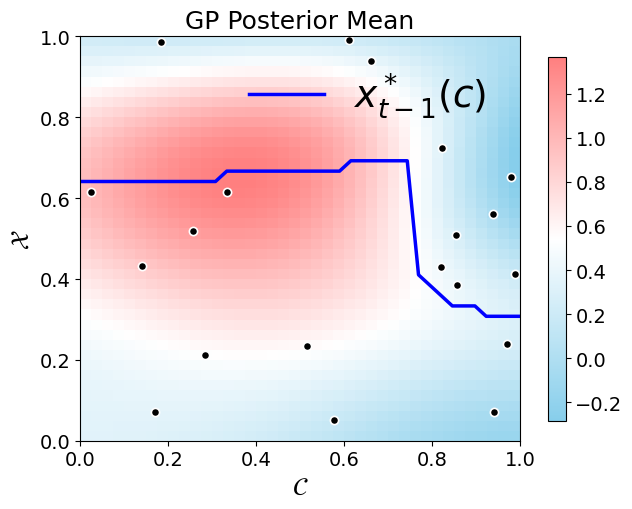

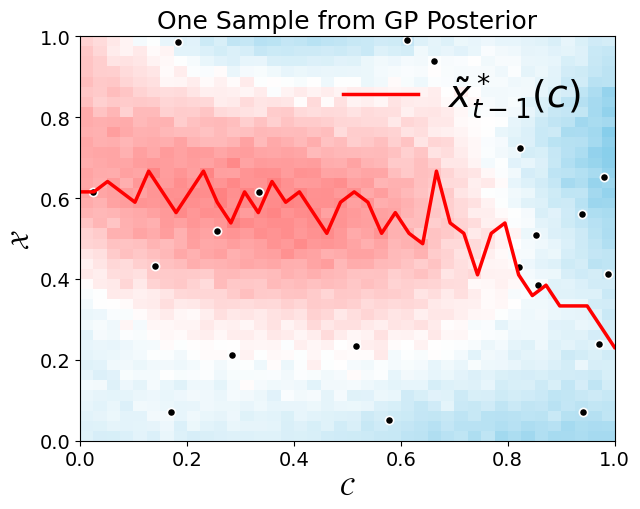

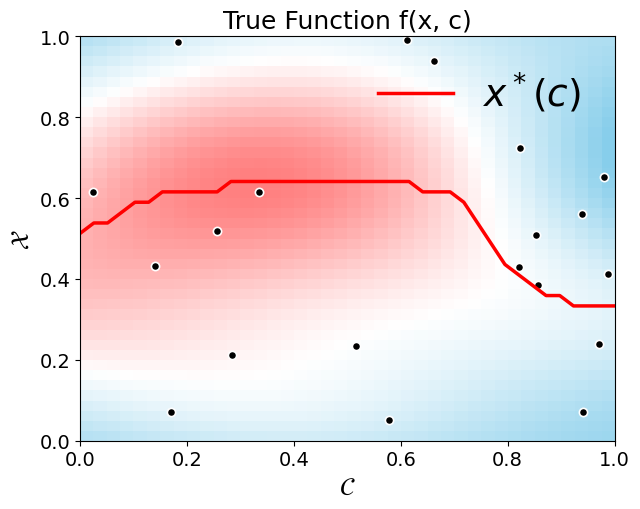

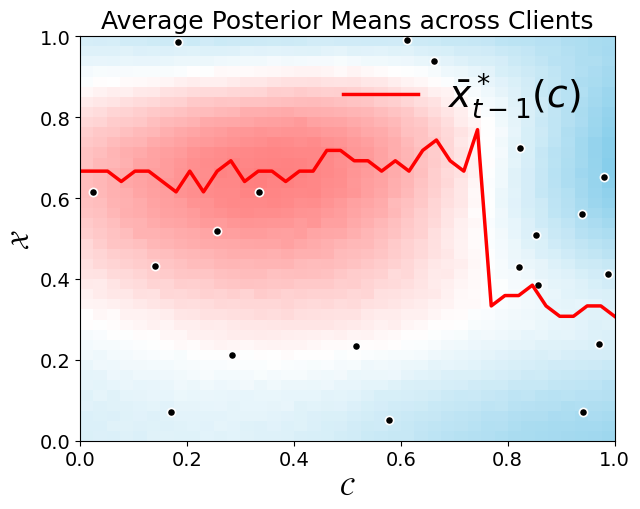

In [5]:
# Faster: smaller grid, avoid return_cov, use sample_y
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

# RNG

# ----- 1) Define a more complex ground-truth f(c, x) -----
def f_true(c, x):
    c = c/1.5
    return (
        np.sin(np.pi * x) * np.cos(np.pi * c)   # base interaction
        + 0.5 * np.sin(2 * np.pi * x * c)       # mixed-frequency term
        + 0.3 * x * c                           # linear interaction
        + 0.2 * np.cos(3 * np.pi * x) * np.sin(2 * np.pi * c)  # higher harmonic cross term
    )

# ----- 2) Sample training data -----
n = 20
rng = np.random.default_rng(seed=4334)  # create a random number generator

C = rng.random(n)
X = rng.random(n)
Y = f_true(C, X) + rng.normal(0, 0.05, size=n)  # small Gaussian noise

train_inputs = np.column_stack([C, X])
train_targets = Y

# ----- 3) Fit a Gaussian Process -----
kernel = 1.0 * RBF(length_scale=[0.2, 0.2], length_scale_bounds=(1e-2, 10.0)) \
         + WhiteKernel(noise_level=1e-2)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, random_state=0)
gp.fit(train_inputs, train_targets)

# ----- 4) Grid for evaluation -----
grid_n = 40  # keep modest for speed
c_lin = np.linspace(0, 1, grid_n)
x_lin = np.linspace(0, 1, grid_n)
C_grid, X_grid = np.meshgrid(c_lin, x_lin, indexing="ij")
grid_points = np.column_stack([C_grid.ravel(), X_grid.ravel()])

# Posterior mean and one sample
mean, std = gp.predict(grid_points, return_std=True)
mean_grid = mean.reshape(grid_n, grid_n)
sample = gp.sample_y(grid_points, n_samples=1, random_state=0).ravel()
sample_grid = sample.reshape(grid_n, grid_n)

# ----- 5) Custom soft colormap: light blue -> white -> light red -----
colors = ["#87CEEB", "white", "#FF7F7F"]  # slightly darker than pastel
soft_cmap = LinearSegmentedColormap.from_list("soft_blue_red", colors)

# Helper to compute x*(c) curve from a Z-grid
def x_star_curve(z_grid, x_axis):
    # For each c index (row), find the x index that maximizes z
    idx = np.argmax(z_grid, axis=1)  # shape: (grid_n,)
    return x_axis[idx]

import matplotlib.pyplot as plt

# Global font settings (applied to all plots)
plt.rcParams.update({
    'font.size': 20,           # base font size
    'axes.labelsize': 18,      # axis label font
    'axes.titlesize': 18,      # title font
    'xtick.labelsize': 14,     # x tick labels
    'ytick.labelsize': 14,     # y tick labels
    'legend.fontsize': 27      # legend font
})
# ----- 6) Plot: Posterior mean + x*(c) -----
plt.figure(figsize=(6.8, 5.5))
im = plt.imshow(mean_grid.T, origin='lower', extent=[0, 1, 0, 1],
                aspect='auto', cmap=soft_cmap)
plt.colorbar(im, shrink=0.9)
plt.scatter(C, X, s=35, edgecolor='white', facecolor='black', linewidth=1.2)  # smaller dots
x_star_mean = x_star_curve(mean_grid, x_lin)
plt.plot(c_lin, x_star_mean, color='blue', linewidth=2.5, label=r'$x_{t-1}^*(c)$')
plt.legend(frameon=False, loc='upper right')
plt.xlabel(r'$\mathcal{C}$')
plt.ylabel(r'$\mathcal{X}$')
plt.title("GP Posterior Mean")
plt.tight_layout()
plt.show()

# ----- 7) Plot: Posterior sample + x*(c) -----
plt.figure(figsize=(6.8, 5.5))
im = plt.imshow(sample_grid.T, origin='lower', extent=[0, 1, 0, 1],
                aspect='auto', cmap=soft_cmap)
plt.scatter(C, X, s=35, edgecolor='white', facecolor='black', linewidth=1.2)
x_star_sample = x_star_curve(sample_grid, x_lin)
plt.plot(c_lin, x_star_sample, color='red', linewidth=2.5, label=r'$\tilde{x}^*_{t-1}(c)$')
plt.legend(frameon=False, loc='upper right')
plt.xlabel(r'$\mathcal{C}$')
plt.ylabel(r'$\mathcal{X}$')
plt.title("One Sample from GP Posterior")
plt.tight_layout()
plt.show()

# ----- Extra: Plot the true function f(c, x) + x*(c) -----
f_grid = f_true(C_grid, X_grid)
plt.figure(figsize=(6.8, 5.5))
im = plt.imshow(f_grid.T, origin='lower', extent=[0, 1, 0, 1],
                aspect='auto', cmap=soft_cmap)
plt.scatter(C, X, s=35, edgecolor='white', facecolor='black', linewidth=1.2)
x_star_true = np.array([x_lin[np.argmax(f_grid[i, :])] for i in range(f_grid.shape[0])])
plt.plot(c_lin, x_star_true, color='red', linewidth=2.5, label=r'$x^*(c)$')
plt.legend(frameon=False, loc='upper right')
plt.xlabel(r'$\mathcal{C}$')
plt.ylabel(r'$\mathcal{X}$')
plt.title("True Function f(x, c)")
plt.tight_layout()
plt.show()

# ----- Extra: Plot the mean of 20 posterior samples -----
samples = gp.sample_y(grid_points, n_samples=20, random_state=1)
mean_of_samples = samples.mean(axis=1)
mean_samples_grid = mean_of_samples.reshape(grid_n, grid_n)

plt.figure(figsize=(6.8, 5.5))
im = plt.imshow(mean_samples_grid.T, origin='lower', extent=[0, 1, 0, 1],
                aspect='auto', cmap=soft_cmap)
plt.scatter(C, X, s=35, edgecolor='white', facecolor='black', linewidth=1.2)
x_star_mean_samples = np.array([x_lin[np.argmax(mean_samples_grid[i, :])]
                                for i in range(mean_samples_grid.shape[0])])
plt.plot(c_lin, x_star_mean_samples, color='red', linewidth=2.5,
         label=r'$\bar{x}_{t-1}^*(c)$')
plt.legend(frameon=False, loc='upper right')
plt.xlabel(r'$\mathcal{C}$')
plt.ylabel(r'$\mathcal{X}$')
plt.title("Average Posterior Means across Clients")
plt.tight_layout()
plt.show()

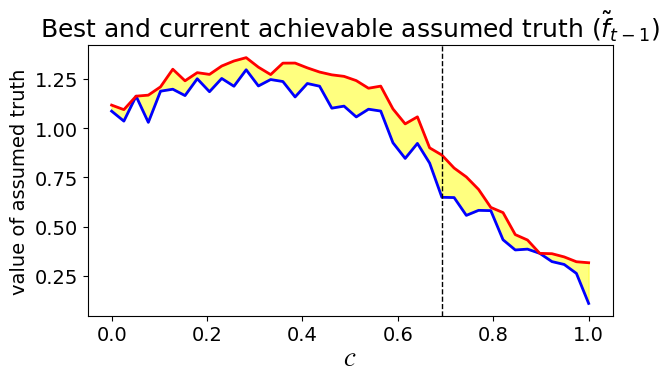

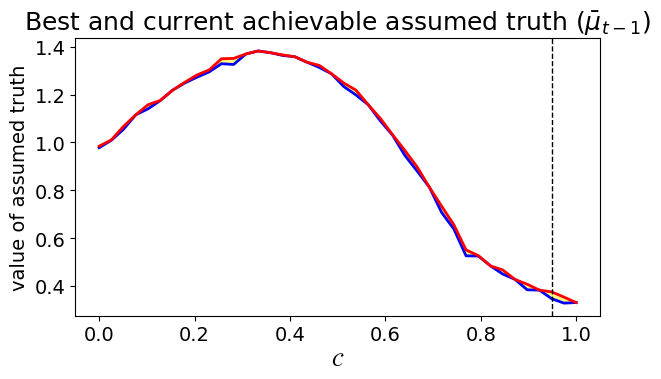

In [6]:
# --- New figure: compare values on the posterior sample ---
# Indices of argmax over x for each c (row-wise)
idx_mean = np.argmax(mean_grid, axis=1)    # columns of x that maximize the posterior mean
idx_samp = np.argmax(sample_grid, axis=1)  # columns of x that maximize the posterior sample
# Evaluate the posterior sample \tilde f at those x's for each c
tildef_mu_star = sample_grid[np.arange(grid_n), idx_mean]         # \tilde f(\mu^*(c), c)
tildef_tilde_star = sample_grid[np.arange(grid_n), idx_samp]      # \tilde f(\tilde f^*(c), c)
# --- New figure: compare values on the averaged posterior mean \bar{\mu} ---
# Indices of argmax over x for each c (row-wise)
idx_mean = np.argmax(mean_grid, axis=1)             # \mu^*(c)
idx_bar = np.argmax(mean_samples_grid, axis=1)      # \bar{\mu}^*(c)
# Evaluate \bar{\mu} at those x's for each c
bar_mu_mu_star = mean_samples_grid[np.arange(grid_n), idx_mean]   # \bar{\mu}(\mu^*(c), c)
bar_mu_bar_star = mean_samples_grid[np.arange(grid_n), idx_bar]   # \bar{\mu}(\bar{\mu}^*(c), c)

# --- Posterior sample plot with yellow gap ---
plt.figure(figsize=(6.5, 4.2))
# Fill the entire gap between curves in yellow
plt.fill_between(
    c_lin,
    tildef_mu_star,
    tildef_tilde_star,
    color='yellow',
    alpha=0.5,
    label='gap'
)
plt.plot(c_lin, tildef_mu_star, color='blue', linewidth=2,
         label=r'$\tilde f_{t-1}(\mu^*_{t-1}(c),\,c)$')
plt.plot(c_lin, tildef_tilde_star, color='red', linewidth=2,
         label=r'$\tilde f_{t-1}(\tilde f^*_{t-1}(c),\,c)$')
# Compute max distance and its index
diff_sample = np.abs(tildef_mu_star - tildef_tilde_star)
imax_sample = np.argmax(diff_sample)
c_max_sample = c_lin[imax_sample]
# Draw vertical black line at that context
plt.axvline(c_max_sample, color='black', linestyle='--', linewidth=1)
plt.xlabel(r'$\mathcal{C}$', fontsize=14)
plt.ylabel('value of assumed truth', fontsize=14)
plt.title(r'Best and current achievable assumed truth ($\tilde{f}_{t-1}$)', fontsize=18)
# plt.legend(frameon=False, fontsize=18)
plt.tight_layout()
plt.show()

# --- Averaged posterior mean plot with yellow gap ---
plt.figure(figsize=(6.5, 4.2))
# Fill the entire gap between curves in yellow
plt.fill_between(
    c_lin,
    bar_mu_mu_star,
    bar_mu_bar_star,
    color='yellow',
    alpha=0.5,
    label='gap'
)
plt.plot(c_lin, bar_mu_mu_star, color='blue', linewidth=2,
         label=r'$\bar{\mu}_{t-1}(\mu^*_{t-1}(c),\,c)$')
plt.plot(c_lin, bar_mu_bar_star, color='red', linewidth=2,
         label=r'$\bar{\mu}_{t-1}(\bar{\mu}^*_{t-1}(c),\,c)$')
# Compute max distance and its index
diff_bar = np.abs(bar_mu_mu_star - bar_mu_bar_star)
imax_bar = np.argmax(diff_bar)
c_max_bar = c_lin[imax_bar]
# Draw vertical black line at that context
plt.axvline(c_max_bar, color='black', linestyle='--', linewidth=1)
plt.xlabel(r'$\mathcal{C}$', fontsize=14)
plt.ylabel('value of assumed truth', fontsize=14)
plt.title(r'Best and current achievable assumed truth ($\bar{\mu}_{t-1}$)', fontsize=18)
# plt.legend(frameon=False, fontsize=18)
plt.tight_layout()
plt.show()